In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

# from qldpc import codes
import networkx as nx
import matplotlib.pyplot as plt
import stim
import sinter

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.QECCode import TestCode

In [2]:
d = 5
hwp = device.default_hwp
dev = device.UnitCellDevice(d+2, d+2, hwp)
code = RotatedSurfaceCode(d)

# Want to optimize ancilla qubit schedules from the middle out, to ensure
# schedules mesh well together
cx,cy = tuple(np.mean(code.qubit_coords, axis=0))
anc_order = []
anc_queue = set(code.X_ancilla_indices)
while anc_queue:
    next_anc = min(anc_queue, key=lambda anc: np.linalg.norm([code.qubit_coords[anc][0]-cx, code.qubit_coords[anc][1]-cy]))
    anc_order.append(next_anc)
    anc_queue.remove(next_anc)
anc_queue = set(code.Z_ancilla_indices)
while anc_queue:
    next_anc = min(anc_queue, key=lambda anc: np.linalg.norm([code.qubit_coords[anc][0]-cx, code.qubit_coords[anc][1]-cy]))
    anc_order.append(next_anc)
    anc_queue.remove(next_anc)

data_coords = {q:((code.qubit_coords[q][0]+1)//2, (code.qubit_coords[q][1]+1)//2) for q in code.data_indices}
assert len(set(data_coords.values())) == len(data_coords)
sched = dev.compile_QEC_schedule(
    code,
    data_coords,
    code.check_cx_layers,
    rounds=1,
    use_highways=True,
    refocus_shuttle_noise=False,
    optimize_ancilla_start=False,
    separate_X_Z=True
)

Optimizing 12 ancilla schedules............
Optimizing 12 ancilla schedules............


In [3]:
[code.qubit_coords[d] for d in code.X_ancilla_indices]

[(2, 0),
 (2, 4),
 (2, 8),
 (4, 2),
 (4, 6),
 (4, 10),
 (6, 0),
 (6, 4),
 (6, 8),
 (8, 2),
 (8, 6),
 (8, 10)]

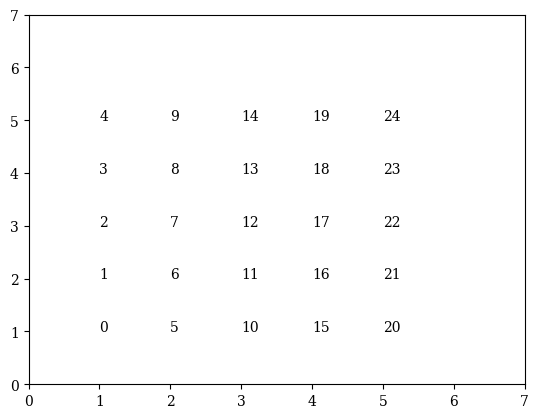

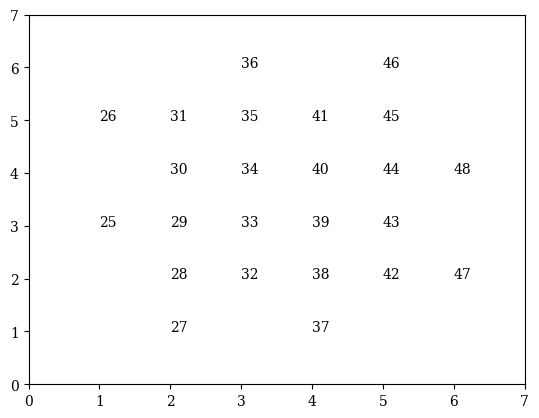

In [4]:
data_init_coords = [((x+1)//2, (y+1)//2) for (x,y) in [code.qubit_coords[q] for q in code.data_indices]]
anc_init_coords = [((x+2)//2, (y+2)//2) for (x,y) in [code.qubit_coords[q] for q in code.X_ancilla_indices + code.Z_ancilla_indices]]

for i,d in enumerate(code.data_indices):
    plt.text(*data_init_coords[i], d)
plt.xlim(0, code.dx+2)
plt.ylim(0, code.dx+2)
plt.show()
for i,a in enumerate(code.X_ancilla_indices + code.Z_ancilla_indices):
    plt.text(*anc_init_coords[i], a)
plt.xlim(0, code.dx+2)
plt.ylim(0, code.dx+2)
plt.show()

In [5]:
code.z_ancilla[code.Z_ancilla_indices.index(28)]

28, Coords: (2, 2), Basis: Z, Data Qubits: [6, Coords: (3, 3), 5, Coords: (3, 1), 1, Coords: (1, 3), 0, Coords: (1, 1)]

In [6]:
code.x_ancilla[code.X_ancilla_indices.index(34)]

34, Coords: (4, 6), Basis: X, Data Qubits: [13, Coords: (5, 7), 8, Coords: (3, 7), 12, Coords: (5, 5), 7, Coords: (3, 5)]

In [7]:
anc_order

[34,
 39,
 32,
 41,
 44,
 29,
 42,
 31,
 36,
 37,
 46,
 27,
 33,
 40,
 35,
 38,
 43,
 30,
 45,
 28,
 48,
 25,
 47,
 26]

In [8]:
for instr,t in zip(sched.instructions, sched.instruction_start_times):
    print(t, instr)

0 Instantiate(duration=500, qubits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], cell_coords=[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5)])
500 EmplaceDisplace(duration=100, qubit=0, coords=(1, 1), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, qubit=1, coords=(1, 2), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, qubit=2, coords=(1, 3), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, qubit=3, coords=(1, 4), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, qubit=4, coords=(1, 5), start_component=READOUT, end_component=INTERACTION_ZONE)
500 EmplaceDisplace(duration=100, qubit=5, coords=(2, 1), start_component=READOUT, e

Issue at t=7300
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
Issue at t=7320
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
Issue at t=7340
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
Issue at t=7360
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
Issue at t=7380
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
Issue at t=7400
	Overlapping: [29, 25] at pos (0.6, 1.8)
	Overlapping: [31, 26] at pos (0.6, 3.8)
	O

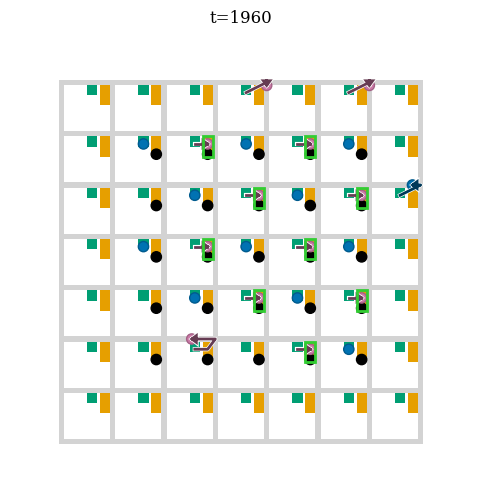

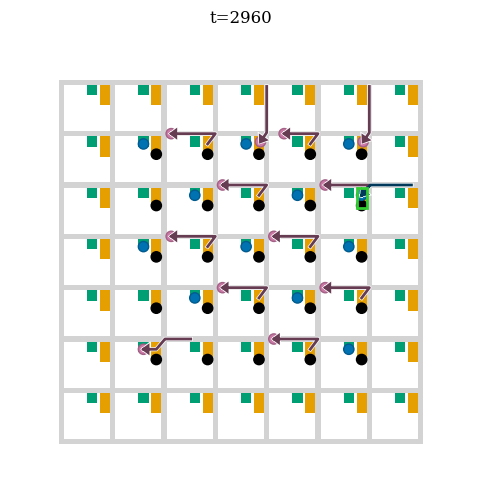

In [9]:
frames = sched.get_frames(20)
print(len(frames))
plotter.plot_transition(dev, code, frames[0:100])
plt.savefig('test.pdf')
plt.show()
plotter.plot_transition(dev, code, frames[100:150])
plt.show()

In [10]:
sched_hand = code.get_schedule(hwp, 'X')
print(sched_hand.total_duration(), sched.total_duration())

7800 12300


In [11]:
circ = sched.to_stim_circuit(code, 'Z', device.error_params(1e-3))
print(circ.without_noise())

QUBIT_COORDS(1, 1) 0
QUBIT_COORDS(1, 3) 1
QUBIT_COORDS(1, 5) 2
QUBIT_COORDS(1, 7) 3
QUBIT_COORDS(1, 9) 4
QUBIT_COORDS(3, 1) 5
QUBIT_COORDS(3, 3) 6
QUBIT_COORDS(3, 5) 7
QUBIT_COORDS(3, 7) 8
QUBIT_COORDS(3, 9) 9
QUBIT_COORDS(5, 1) 10
QUBIT_COORDS(5, 3) 11
QUBIT_COORDS(5, 5) 12
QUBIT_COORDS(5, 7) 13
QUBIT_COORDS(5, 9) 14
QUBIT_COORDS(7, 1) 15
QUBIT_COORDS(7, 3) 16
QUBIT_COORDS(7, 5) 17
QUBIT_COORDS(7, 7) 18
QUBIT_COORDS(7, 9) 19
QUBIT_COORDS(9, 1) 20
QUBIT_COORDS(9, 3) 21
QUBIT_COORDS(9, 5) 22
QUBIT_COORDS(9, 7) 23
QUBIT_COORDS(9, 9) 24
QUBIT_COORDS(0, 4) 25
QUBIT_COORDS(0, 8) 26
QUBIT_COORDS(2, 0) 27
QUBIT_COORDS(2, 2) 28
QUBIT_COORDS(2, 4) 29
QUBIT_COORDS(2, 6) 30
QUBIT_COORDS(2, 8) 31
QUBIT_COORDS(4, 2) 32
QUBIT_COORDS(4, 4) 33
QUBIT_COORDS(4, 6) 34
QUBIT_COORDS(4, 8) 35
QUBIT_COORDS(4, 10) 36
QUBIT_COORDS(6, 0) 37
QUBIT_COORDS(6, 2) 38
QUBIT_COORDS(6, 4) 39
QUBIT_COORDS(6, 6) 40
QUBIT_COORDS(6, 8) 41
QUBIT_COORDS(8, 2) 42
QUBIT_COORDS(8, 4) 43
QUBIT_COORDS(8, 6) 44
QUBIT_COORDS(8, 8) 

In [12]:
print(circ.to_crumble_url())

sinter.collect(
    num_workers=6,
    tasks=[sinter.Task(
        circuit=circ,
    )],
    max_shots=10**6,
    max_errors=500,
    decoders='pymatching'
)

https://algassert.com/crumble#circuit=Q(1,1)0;Q(1,3)1;Q(1,5)2;Q(1,7)3;Q(1,9)4;Q(3,1)5;Q(3,3)6;Q(3,5)7;Q(3,7)8;Q(3,9)9;Q(5,1)10;Q(5,3)11;Q(5,5)12;Q(5,7)13;Q(5,9)14;Q(7,1)15;Q(7,3)16;Q(7,5)17;Q(7,7)18;Q(7,9)19;Q(9,1)20;Q(9,3)21;Q(9,5)22;Q(9,7)23;Q(9,9)24;Q(0,4)25;Q(0,8)26;Q(2,0)27;Q(2,2)28;Q(2,4)29;Q(2,6)30;Q(2,8)31;Q(4,2)32;Q(4,4)33;Q(4,6)34;Q(4,8)35;Q(4,10)36;Q(6,0)37;Q(6,2)38;Q(6,4)39;Q(6,6)40;Q(6,8)41;Q(8,2)42;Q(8,4)43;Q(8,6)44;Q(8,8)45;Q(8,10)46;Q(10,2)47;Q(10,6)48;R_0_1_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21_22_23_24;X_ERROR(0.001)0_1_2_3_4_5_6_7_8_9_10_11_12_13_14_15_16_17_18_19_20_21_22_23_24;Z_ERROR(1e-06)24_15_18_19_20_17_16_12_11_4_2_0_3_14_1_8_23_10_9_6_7_22_21_5_13;R_27_29_31_32_34_36_37_39_41_42_44_46;X_ERROR(0.001)27_29_31_32_34_36_37_39_41_42_44_46;R_25_26_28_30_33_35_38_40_43_45_47_48;X_ERROR(0.001)25_26_28_30_33_35_38_40_43_45_47_48;H_27_29_31_32_34_36_37_39_41_42_44_46;DEPOLARIZE1(0.001)27_29_31_32_34_36_37_39_41_42_44_46;Z_ERROR(1e-06)27;Z_ERROR(0.0069755

[sinter.TaskStats(strong_id='b2bbaf41398fe12d4d3db5661024bf1e319a42952ada6c2ef3fa479d55504dd9', decoder='pymatching', json_metadata=None, shots=1000000, errors=5, seconds=0.18740082532167435)]

In [13]:
print(code.get_stim('Z', 1, 1e-3, 1e-3))

IndexError: index 1 is out of bounds for axis 0 with size 1

In [14]:
print(code.get_stim('Z', 1, 1e-3, 1e-3).to_crumble_url())

IndexError: index 1 is out of bounds for axis 0 with size 1

In [15]:
print(circ)

QUBIT_COORDS(1, 1) 0
QUBIT_COORDS(1, 3) 1
QUBIT_COORDS(1, 5) 2
QUBIT_COORDS(1, 7) 3
QUBIT_COORDS(1, 9) 4
QUBIT_COORDS(3, 1) 5
QUBIT_COORDS(3, 3) 6
QUBIT_COORDS(3, 5) 7
QUBIT_COORDS(3, 7) 8
QUBIT_COORDS(3, 9) 9
QUBIT_COORDS(5, 1) 10
QUBIT_COORDS(5, 3) 11
QUBIT_COORDS(5, 5) 12
QUBIT_COORDS(5, 7) 13
QUBIT_COORDS(5, 9) 14
QUBIT_COORDS(7, 1) 15
QUBIT_COORDS(7, 3) 16
QUBIT_COORDS(7, 5) 17
QUBIT_COORDS(7, 7) 18
QUBIT_COORDS(7, 9) 19
QUBIT_COORDS(9, 1) 20
QUBIT_COORDS(9, 3) 21
QUBIT_COORDS(9, 5) 22
QUBIT_COORDS(9, 7) 23
QUBIT_COORDS(9, 9) 24
QUBIT_COORDS(0, 4) 25
QUBIT_COORDS(0, 8) 26
QUBIT_COORDS(2, 0) 27
QUBIT_COORDS(2, 2) 28
QUBIT_COORDS(2, 4) 29
QUBIT_COORDS(2, 6) 30
QUBIT_COORDS(2, 8) 31
QUBIT_COORDS(4, 2) 32
QUBIT_COORDS(4, 4) 33
QUBIT_COORDS(4, 6) 34
QUBIT_COORDS(4, 8) 35
QUBIT_COORDS(4, 10) 36
QUBIT_COORDS(6, 0) 37
QUBIT_COORDS(6, 2) 38
QUBIT_COORDS(6, 4) 39
QUBIT_COORDS(6, 6) 40
QUBIT_COORDS(6, 8) 41
QUBIT_COORDS(8, 2) 42
QUBIT_COORDS(8, 4) 43
QUBIT_COORDS(8, 6) 44
QUBIT_COORDS(8, 8) 

In [16]:
code.X_ancilla_indices

[27, 29, 31, 32, 34, 36, 37, 39, 41, 42, 44, 46]

In [17]:
circ = sched_hand.to_stim_circuit(code, 'Z', hwp)

print(circ.to_crumble_url())

sinter.collect(
    num_workers=6,
    tasks=[sinter.Task(
        circuit=circ,
    )],
    max_shots=10**6,
    max_errors=500,
    decoders='pymatching'
)

AttributeError: 'HardwareParams' object has no attribute 'init_err'

In [ ]:
frames = sched_hand.get_frames(10)
# plotter.plot_device_snapshot(dev, code, frames[50])
anim = plotter.animate_device(dev, code, frames, 'anim_surface_hand.gif', fps=30)

MovieWriter imagemagick unavailable; using Pillow instead.


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x758117eb2c00> (for post_execute), with arguments args (),kwargs {}:


IndexError: list index out of range

IndexError: list index out of range

<Figure size 640x480 with 1 Axes>

: 

In [ ]:
frames = sched.get_frames(10)
# plotter.plot_device_snapshot(dev, code, frames[50])
anim = plotter.animate_device(dev, code, frames, 'anim_surface.gif', fps=30)